# Banking Customer Churn Analysis

Customer churn is a major concern in the banking industry, as it directly impacts profitability, customer lifetime value, and long-term business
sustainability.In today’s highly competitive financial market, customers have numerous alternatives, making it easier for them to switch banks if 
their expectations are not met. Therefore, understanding the factors that lead to customer churn has become essential for banks aiming to retain
their clients and maintain a strong market position.
    This project focuses on analyzing a bank’s customer dataset to identify patterns and trends associated with churn behavior. By examining variables such as customer demographics, account details, and transaction-related features, the analysis aims to uncover key drivers influencing customer decisions to leave the bank. Data cleaning and preprocessing play a crucial role in ensuring the accuracy and reliability of the analysis, especially when dealing with missing or inconsistent data. Exploratory Data Analysis (EDA) is used to visualize relationships between different variables and the churn status, helping to reveal hidden insights. Various statistical and visualization techniques are applied to better understand customer segments that are more likely to churn. The findings from this project can assist banks in developing targeted retention strategies and improving customer satisfaction.Ultimately, this analysis provides valuable insights that can help reduce churn rates and enhance overall business performance.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
url = "https://docs.google.com/spreadsheets/d/1Nbnsy4gGkZ1fvO0y4H8mzbsmfGif_cy4/export?format=xlsx"
df1 = pd.read_excel(url, sheet_name="Customer_Info")
df2 = pd.read_excel(url, sheet_name="Account_Info")

Next step shows the first 5 rows of both tables.

In [6]:
display(df1.head())
display(df2.head())

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


Merge the two tables using CustomerId and print the first 5 rows

In [7]:
df = pd.merge(df1, df2, on="CustomerId", how="outer")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15565701,Ferri,698,Spain,Female,39.0,9,€90212.38,€161993.89,1,No,9,No,0
1,15565706,Akobundu,612,Spain,Male,35.0,1,€83256.26,€0.0,1,Yes,1,Yes,1
2,15565714,Cattaneo,601,France,Male,47.0,1,€96517.97,€64430.06,2,Yes,1,Yes,0
3,15565779,Kent,627,Germany,Female,30.0,6,€188258.49,€57809.32,1,No,6,No,0
4,15565796,Docherty,745,Germany,Male,48.0,10,€74510.65,€96048.55,1,No,10,No,0


The merged data contains two columns named Tenure_x and Tenure_y which carries same data.Therefore Dropping the column Tenure_y

In [8]:
df = df.drop('Tenure_y', axis=1)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15565701,Ferri,698,Spain,Female,39.0,9,€90212.38,€161993.89,1,No,No,0
1,15565706,Akobundu,612,Spain,Male,35.0,1,€83256.26,€0.0,1,Yes,Yes,1
2,15565714,Cattaneo,601,France,Male,47.0,1,€96517.97,€64430.06,2,Yes,Yes,0
3,15565779,Kent,627,Germany,Female,30.0,6,€188258.49,€57809.32,1,No,No,0
4,15565796,Docherty,745,Germany,Male,48.0,10,€74510.65,€96048.55,1,No,No,0


In [9]:
df.shape

(10004, 13)

This data set contains 10004 rows and 13 columns

In [10]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure_x', 'EstimatedSalary', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'Exited'],
      dtype='object')

In [11]:
df.describe()

,CustomerId,CreditScore,Age,Tenure_x,NumOfProducts,Exited
count,1.000400e+04,10004.000000,10001.000000,10004.000000,10004.000000,10004.000000
mean,1.569092e+07,650.568073,38.919108,5.012195,1.529988,0.203719
std,7.193218e+04,96.665531,10.488725,2.891806,0.581635,0.402782
min,1.556570e+07,350.000000,18.000000,0.000000,1.000000,0.000000
25%,1.562839e+07,584.000000,32.000000,3.000000,1.000000,0.000000
50%,1.569071e+07,652.000000,37.000000,5.000000,1.000000,0.000000
75%,1.575322e+07,718.000000,44.000000,7.000000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,4.000000,1.000000


This shows the statistical summary of numerical columns in the DataFrame

In [12]:
#Replace '?' with 'NaN'
df.replace('?', np.nan, inplace=True)

In [13]:
print("Missing values count")
df.isnull().sum()

Missing values count


CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure_x           0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

 This step checks for the count of missing values in each columns.It shows that there are three missing values in both Surname and Age.Since Surname is not necessary for the analysis,we can drop that column.For Age the missing value can be filled with the mean value.

In [14]:
df = df.drop('Surname', axis=1)
df.fillna(df.mean(numeric_only=True), inplace=True)
print("Missing values count")
df.isnull().sum()

Missing values count


CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure_x           0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [15]:
print("Duplicate rows count:",df.duplicated().sum())

Duplicate rows count: 4


This data set contains 4 duplicates row that is needed to remove.

In [16]:
df.drop_duplicates(inplace=True)
print("Duplicate rows count:",df.duplicated().sum())

Duplicate rows count: 0


In [17]:
df['EstimatedSalary'] = df['EstimatedSalary'].str.replace('€','')
df['Balance'] = df['Balance'].str.replace('€','')
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15565701,698,Spain,Female,39.0,9,90212.38,161993.89,1,No,No,0
1,15565706,612,Spain,Male,35.0,1,83256.26,0.0,1,Yes,Yes,1
2,15565714,601,France,Male,47.0,1,96517.97,64430.06,2,Yes,Yes,0
3,15565779,627,Germany,Female,30.0,6,188258.49,57809.32,1,No,No,0
4,15565796,745,Germany,Male,48.0,10,74510.65,96048.55,1,No,No,0


In this step, symbol before the Estimated Salary and Balance is removed.

In [18]:
numeric_cols = ['CreditScore', 'Age', 'Tenure_x', 'Balance', 'EstimatedSalary']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [19]:
df.dtypes

CustomerId           int64
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure_x             int64
EstimatedSalary    float64
Balance            float64
NumOfProducts        int64
HasCrCard           object
IsActiveMember      object
Exited               int64
dtype: object

In [20]:
df['CustomerId'] = df['CustomerId'].astype(str)
df['Age'] = df['Age'].astype(int)
df.dtypes

CustomerId          object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure_x             int64
EstimatedSalary    float64
Balance            float64
NumOfProducts        int64
HasCrCard           object
IsActiveMember      object
Exited               int64
dtype: object

Data type of CustomerId is converted into String and that of Age into int.

In [21]:
df.rename(columns={'Exited':'Churned'}, inplace=True) 
df.rename(columns={'Tenure_x':'Tenure'}, inplace=True)
df['Churned'] = df['Churned'].map({0:'No',1:'Yes'}) 
df['HasCrCard'] = df['HasCrCard'].astype('category')
df['IsActiveMember'] = df['IsActiveMember'].astype('category')
df['Churned'] = df['Churned'].astype('category')
df.head()


,CustomerId,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Churned
0,15565701,698,Spain,Female,39,9,90212.38,161993.89,1,No,No,No
1,15565706,612,Spain,Male,35,1,83256.26,0.00,1,Yes,Yes,Yes
2,15565714,601,France,Male,47,1,96517.97,64430.06,2,Yes,Yes,No
3,15565779,627,Germany,Female,30,6,188258.49,57809.32,1,No,No,No
4,15565796,745,Germany,Male,48,10,74510.65,96048.55,1,No,No,No


In [22]:
df.dtypes

CustomerId           object
CreditScore           int64
Geography            object
Gender               object
Age                   int64
Tenure                int64
EstimatedSalary     float64
Balance             float64
NumOfProducts         int64
HasCrCard          category
IsActiveMember     category
Churned            category
dtype: object

In [23]:
df['Geography'] = df['Geography'].str.strip().str.lower()
df['Geography'] = df['Geography'].replace({
    'fra': 'france',
    'french': 'france'
})
df['Geography'] = df['Geography'].str.title()
df['Geography'].unique()

array(['Spain', 'France', 'Germany'], dtype=object)

Solved the incosistencies in the Geography values

In [24]:
total_customers = df.shape[0]
churned_customers = df[df['Churned'] == 'Yes'].shape[0]
non_churned_customers = total_customers - churned_customers
churn_rate = round((churned_customers / total_customers) * 100,2)

print("Total Customers:",total_customers)
print("Churned_customers:",churned_customers)
print("Non_churned_customers:",non_churned_customers)
print("Churn Rate:",churn_rate)

Total Customers: 10000
Churned_customers: 2037
Non_churned_customers: 7963
Churn Rate: 20.37


In [25]:
female_customers = df[df['Gender'] == 'Female'].shape[0]
male_customers = df[df['Gender'] == 'Male'].shape[0]
churned_female = df[(df['Gender'] == 'Female') & (df['Churned'] == 'Yes')].shape[0]
churned_male = df[(df['Gender'] == 'Male') & (df['Churned'] == 'Yes')].shape[0]

print("Total Female Customers:",female_customers)
print("Churned Female customers count:",churned_female)
print("Total Male Customers:",male_customers)
print("Churned Male customers count:",churned_male)

Total Female Customers: 4543
Churned Female customers count: 1139
Total Male Customers: 5457
Churned Male customers count: 898


In [26]:
creditcard_customers = df[df['HasCrCard'] == 'Yes'].shape[0]
churned_creditcdcust = df[(df['HasCrCard'] == 'Yes') & (df['Churned'] == 'Yes')].shape[0]
nonchurned_creditcdcust = creditcard_customers-churned_creditcdcust
print("Total no.of customers having credit card:",female_customers)
print("Count of churned customers having credit card:",churned_creditcdcust)
print("Count of non-churned customers having credit card:",nonchurned_creditcdcust)

Total no.of customers having credit card: 4543
Count of churned customers having credit card: 735
Count of non-churned customers having credit card: 4416


In [27]:
active_customers = df[df['IsActiveMember'] == 'Yes'].shape[0]
churned_activecust = df[(df['IsActiveMember'] == 'Yes') & (df['Churned'] == 'Yes')].shape[0]
nonchurned_activecust = active_customers-churned_activecust
print("Count of active Members:",active_customers)
print("Count of churned active customers:",churned_activecust)
print("Count of non-churned active customers :",nonchurned_activecust)

Count of active Members: 5151
Count of churned active customers: 735
Count of non-churned active customers : 4416


In [28]:
summary2 = pd.DataFrame({
    'Metric': ['Total', 'Churned', 'Non-Churned'],
    'Overall': [total_customers, churned_customers, non_churned_customers],
    'Female': [female_customers, churned_female, female_customers - churned_female],
    'Male': [male_customers, churned_male, male_customers - churned_male],
    'Credit Card Holders': [creditcard_customers, churned_creditcdcust, nonchurned_creditcdcust],
    'Active Members': [active_customers, churned_activecust, nonchurned_activecust]
})

summary2

,Metric,Overall,Female,Male,Credit Card Holders,Active Members
0,Total,10000,4543,5457,5151,5151
1,Churned,2037,1139,898,735,735
2,Non-Churned,7963,3404,4559,4416,4416


This table shows the overall distribution of Churned and non churned customers on various parameters.

C:\Users\mariy\AppData\Local\Temp\ipykernel_27828\2653409725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churned', data=df,palette=colors)


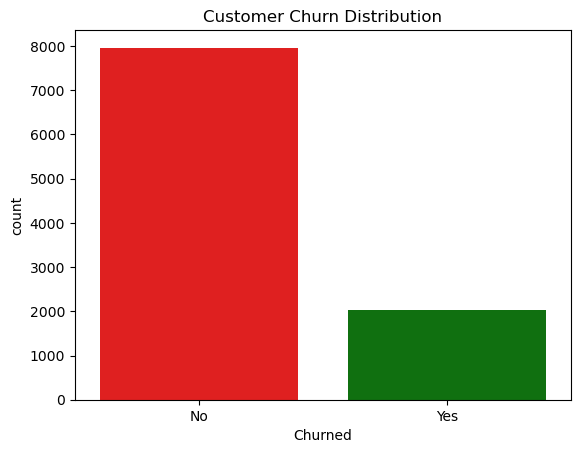

In [36]:
colors = [ 'red','green']
sns.countplot(x='Churned', data=df,palette=colors)
plt.title("Customer Churn Distribution")
plt.show()

A bar graph is generated to visualize the customer churn distribution with different colors for churned and non-churned customers.

* The chart shows that non-churned customers are higher than churned customers.
* The bank retains most of its customers, which is a positive sign.
* Even though retention is high, churn is not negligible and needs attention.

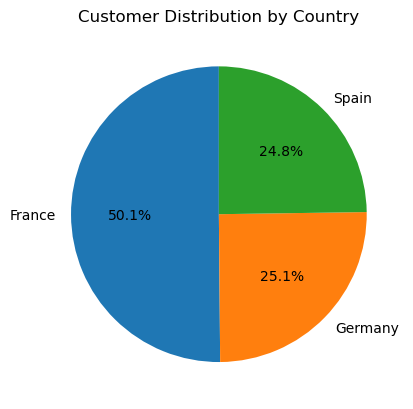

In [54]:
country_dist = df['Geography'].value_counts()
plt.pie(country_dist,
        labels=country_dist.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Customer Distribution by Country')
plt.show()

A pie chart is used to visualize the distribution of customers in various countries.
* The chart shows that majority of the customers resides in France and the remaining are distributed equally among Spain
  and Germany.

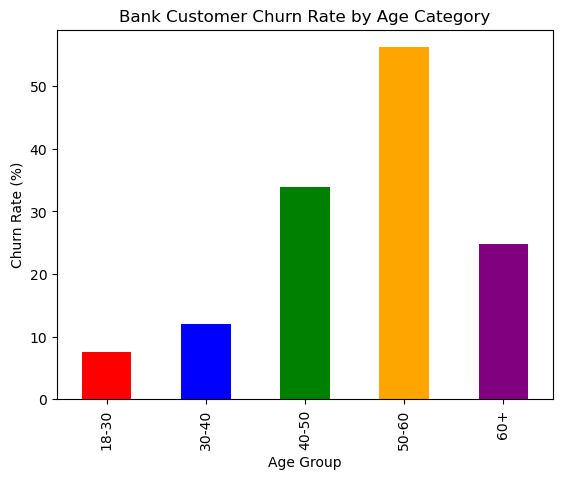

In [38]:
df['AgeGroup'] = pd.cut(df['Age'],bins=[18, 30, 40, 50, 60, 100],labels=['18-30', '30-40', '40-50', '50-60', '60+'])
churn_age = df.groupby('AgeGroup',observed=True)['Churned'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_age = churn_age.round(2)

churn_age.plot(kind='bar',color = ['red', 'blue', 'green', 'orange', 'purple'])
plt.title('Bank Customer Churn Rate by Age Category')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.show()


This analysis groups customers into age categories (e.g.,18-30,30-40 etc.) and shows how churn varies across these groups.
A bar chart is used for the analysis.
* Older or senior customers typically show a higher churn rate.
     Older customers may switch banks due to better offers, service dissatisfaction, or changing financial needs.
* Lower Churn in Middle-Aged Customers and younger customers.
     This group is usually more financially stable and loyal, maintaining long-term relationships with the ban


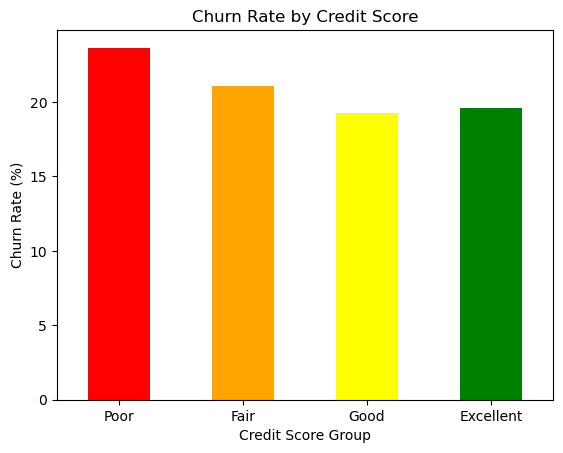

In [39]:
df['CreditScoreGroup'] = pd.cut(df['CreditScore'],
                                bins=[300, 500, 650, 750, 850],
                                labels=['Poor', 'Fair', 'Good', 'Excellent'])
churn_cs = df.groupby('CreditScoreGroup', observed=True)['Churned'] \
             .apply(lambda x: (x == 'Yes').mean() * 100)

churn_cs = churn_cs.round(2)

churn_cs.plot(kind='bar',color = ['red', 'orange', 'yellow', 'green'])
plt.title('Churn Rate by Credit Score')
plt.xlabel('Credit Score Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

This analysis shows how customer churn varies across different credit score ranges.
* Customers with low credit scores tend to show higher churn rates.
These customers may face financial difficulties or may not qualify for favorable banking services, leading to dissatisfaction.
* Customers with high credit scores usually have lower churn rates.
They are financially stable and likely receive better services, making them more loyal.

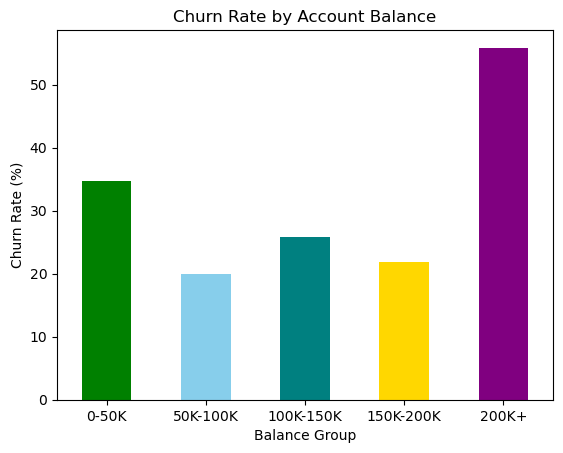

In [40]:
df['BalanceGroup'] = pd.cut(df['Balance'],bins=[0, 50000, 100000, 150000, 200000, 300000],
                            labels=['0-50K', '50K-100K', '100K-150K', '150K-200K', '200K+'])
churn_balance = df.groupby('BalanceGroup', observed=True)['Churned'] \
                  .apply(lambda x: (x == 'Yes').mean() * 100)

churn_balance = churn_balance.round(2)
churn_balance.plot(kind='bar',color = ['green', 'skyblue', 'teal', 'gold', 'purple'])
plt.title('Churn Rate by Account Balance')
plt.xlabel('Balance Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

A bar graph is generated to analyze the churn rate by account balance.
* Churn rate is highest in very high account balance customers.These customers may expect premium services or switch for better investment/benefits.
* Churn rate is high in low balance group.Low-balance customers may have low engagement or not see enough value in the bank.
* Churn rate is relatively low in middle group.

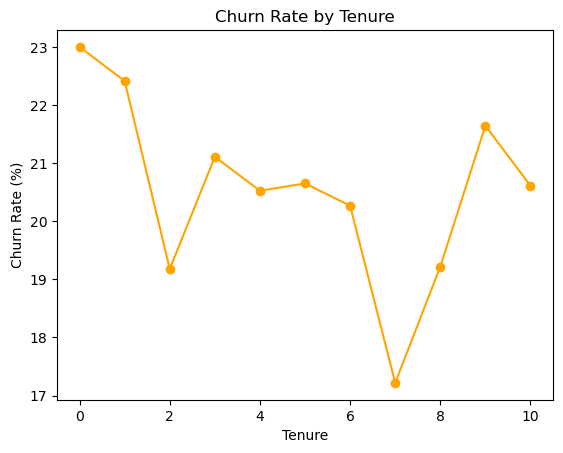

In [43]:
churn_tenure = df.groupby('Tenure', observed=True)['Churned'] \
                 .apply(lambda x: (x == 'Yes').mean() * 100)

churn_tenure.plot(kind='line', marker='o',color='orange')

plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Churn Rate (%)')
plt.show()

A line graph is used to demonstrate the relation between churn rate and tenure in years.
* Higher Churn at Early Tenure (0–1 Years).Churn rate is highest (~22–23%) at tenure 0–1.
* Drop in Churn After Initial Years. Churn decreases around tenure 2 (~19%).
* Stable Churn in Mid Tenure (3–6 Years). Churn fluctuates slightly around 20–21%.
* Lowest Churn at Tenure 7.Churn reaches lowest (~17%).
* Slight Increase Again in Later Years (8–9).Churn rises again (~19–21%).Even long-term customers may leave due to:
    * Better offers elsewhere
    * Changing financial needs

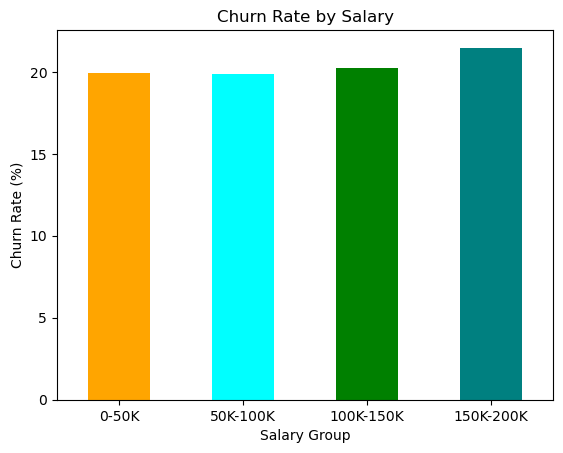

In [45]:
df['SalaryGroup'] = pd.cut(df['EstimatedSalary'],bins=[0, 50000, 100000, 150000, 200000],
                           labels=['0-50K', '50K-100K', '100K-150K', '150K-200K'])
churn_salary = df.groupby('SalaryGroup', observed=True)['Churned'] \
    .apply(lambda x: (x == 'Yes').mean() * 100)
churn_salary = churn_salary.round(2)
churn_salary.plot(kind='bar',color = ['orange', 'cyan', 'green', 'teal', 'magenta'])
plt.title('Churn Rate by Salary')
plt.xlabel('Salary Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

This bar chart helps to identify the relation between churn rate and salary.
* Minimal Variation Across Salary Groups. Churn ranges only from ~20% to ~22%. Salary has very weak impact on churn behavior.
* Salary is a Weak Predictor in churn anlaysis.

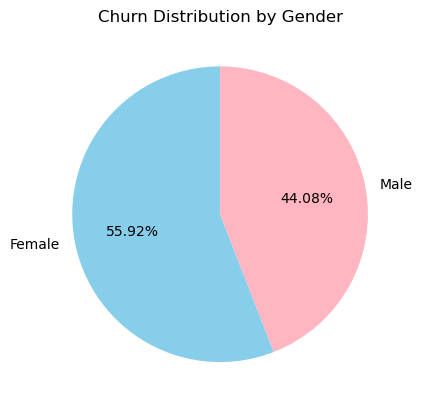

In [46]:
churned_gender = df[df['Churned'] == 'Yes']['Gender'].value_counts()
plt.pie(churned_gender,
        labels=churned_gender.index,
        autopct='%1.2f%%',
        startangle=90,colors = ['skyblue', 'lightpink'])
plt.title('Churn Distribution by Gender')
plt.show()

Pie chart is generated to  show the churn distribution among males and females.
* Higher Churn Among Female Customers. Female customers typically show a higher churn rate compared to males.

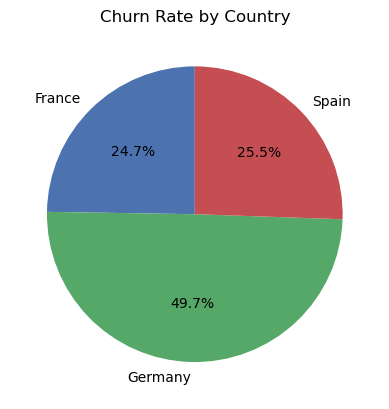

In [51]:
churn_country = df.groupby('Geography', observed=True)['Churned'] \
                  .apply(lambda x: (x == 'Yes').mean() * 100)
churn_country = churn_country.round(2)
plt.pie(churn_country,
        labels=churn_country.index,
        autopct='%1.1f%%',
        startangle=90,colors=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Churn Rate by Country')
plt.show()

A pie graph is used to analyze the churn rate by country.
* Germany shows the highest churn rate.
* Both France and Spain shows low churn rate(~25%).

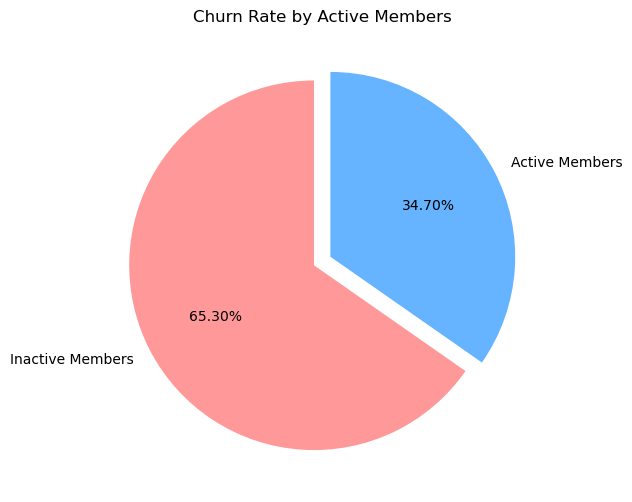

In [271]:
df['ChurnValue'] = df['Churned'].map({'Yes': 1, 'No': 0})
df['ChurnValue'] = pd.to_numeric(df['ChurnValue'], errors='coerce')  # converts invalids to NaN
numeric_df = df.select_dtypes(include=['number'])
# Group by active membership status and calculate churn rate
churn_active = df.groupby('IsActiveMember', observed=True)['ChurnValue'].mean() * 100
churn_active = churn_active.reset_index()
churn_active.columns = ['IsActiveMember', 'ChurnRate']

# Prepare labels and values
labels = ['Inactive Members', 'Active Members']
values = churn_active['ChurnRate'].values

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.2f%%', startangle=90, colors=colors, explode=(0.05, 0.05))
plt.title('Churn Rate by Active Members')
plt.show()

A pie chart is generated to analyze the churn rate by active or inactive customers.
* Inactive members have a significantly higher churn rate compared to active members.
* Active members are more loyal and less likely to leave.

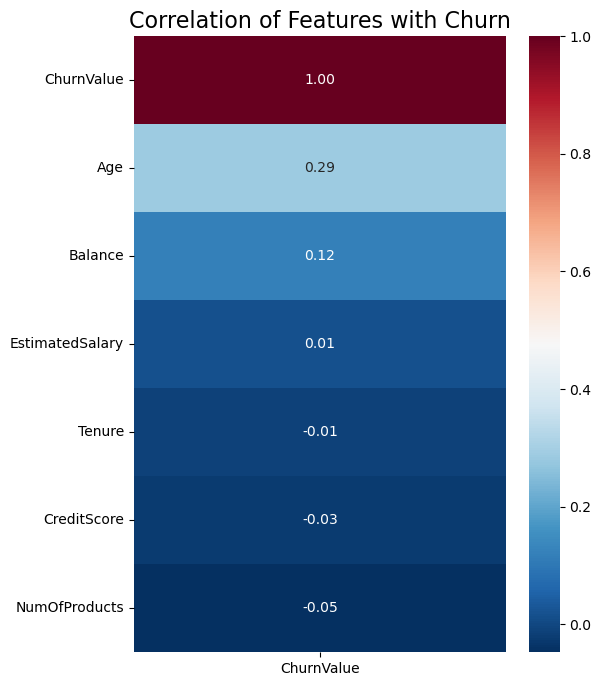

In [53]:
df['ChurnValue'] = df['Churned'].map({'Yes': 1, 'No': 0})
df['ChurnValue'] = pd.to_numeric(df['ChurnValue'], errors='coerce')
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

churn_corr = corr[['ChurnValue']].sort_values(by='ChurnValue', ascending=False)
plt.figure(figsize=(6,8))

sns.heatmap(
    churn_corr,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r'
)

plt.title("Correlation of Features with Churn", fontsize=16)
plt.show()

* Age and Account balance shows strong positive corelation with churn.
* Salary doesn't shows that much dependencies on churn.
* Credit score and no.of products shows negative corelation on churn rate.

# Key Insights

The bank retains most of its customers, which is a positive sign.Even though retention is high, churn is not negligible and needs attention.The factors
affecting the churn rate are as follows.
* Age : Churn rate is higher among olderor senior customers.
* Credit score : Customers with low credit scores tend to show higher churn rates.
* Account Balance : Customers having both high and low account balance shows higher churn rate.
* Tenure : High churn rate in early stagges.
* Salary : Churn is not dependent on the salary.
* Geography: Germany is having higher churn rate.
* Gender : Female customers tends to churn more compared to males.
* Inactive customers churn more compared to active ones.
